In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\user\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
df = pd.read_csv("loan.csv")
df.head(2)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N


In [3]:
# Before Encoding
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 83.4 KB


In [4]:
df.describe()
# give info ONLY about Numerical columns

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [5]:
df.shape
# gives (no. of rows, no. of cols)

(614, 13)

In [6]:
df.size
# no. of rows * no. of cols = total no. of elements present

7982

In [7]:
print(df.duplicated().sum())

0


In [8]:
df.drop("Loan_ID", axis=1, inplace=True)
df.head(2)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N


In [9]:
df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']
df.drop(['ApplicantIncome','CoapplicantIncome'], axis=1, inplace=True)

In [10]:
df.head(2)

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income
0,Male,No,0,Graduate,No,NaN,360.0,1.0,Urban,Y,5849.0
1,Male,Yes,1,Graduate,No,128.0,360.0,1.0,Rural,N,6091.0


In [11]:
x = df.drop('Loan_Status', axis=1) # I/P data
y = df['Loan_Status'] # O/P data

print("Shape of x:", x.shape)
print("Shape of y:", y.shape)

Shape of x: (614, 10)
Shape of y: (614,)


In [12]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

In [13]:
print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("y_train shape:", y_train.shape) # O/P: (491,) --> no value after ','  , coz y_train and y_test are 'Series', not 'DataFrame'
print("y_test shape:", y_test.shape) # 0.2 * 614 --> 123, so 123 data rows gone for 'Testing'

x_train shape: (491, 10)
x_test shape: (123, 10)
y_train shape: (491,)
y_test shape: (123,)


In [14]:
x_train.isnull().sum()

Gender              12
Married              1
Dependents          11
Education            0
Self_Employed       24
LoanAmount          16
Loan_Amount_Term    12
Credit_History      40
Property_Area        0
Total_Income         0
dtype: int64

In [15]:
# Percentage of Null values in each column
# Percentage of given object = (total no. of those objects / total no. of objects) * 100

(x_train.isnull().sum() / x_train.shape[0]) * 100

# df.shape[0], gives the total no. of rows in our dataset

Gender              2.443992
Married             0.203666
Dependents          2.240326
Education           0.000000
Self_Employed       4.887984
LoanAmount          3.258656
Loan_Amount_Term    2.443992
Credit_History      8.146640
Property_Area       0.000000
Total_Income        0.000000
dtype: float64

In [16]:
# Total Null values present
x_train.isnull().sum().sum()

np.int64(116)

In [17]:
# Percentage of Total Null values in the overall dataset
(x_train.isnull().sum().sum() / x_train.size) * 100

np.float64(2.3625254582484727)

# Filling Null values in columns using Mean or Median or Mode

In [18]:
# Filling all the Categorical columns with their Mode
for col in x_train.select_dtypes(include=['object']).columns:
    most_freq = x_train[col].mode()[0]
    x_train[col] = x_train[col].fillna(most_freq)
    x_test[col] = x_test[col].fillna(most_freq)

C:\Users\user\AppData\Local\Temp\ipykernel_12648\2942858963.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in x_train.select_dtypes(include=['object']).columns:


In [19]:
# Filling all the Numerical columns with their Mode
x_train['LoanAmount'] = x_train['LoanAmount'].fillna(x_train['LoanAmount'].median())
x_test['LoanAmount'] = x_test['LoanAmount'].fillna(x_train['LoanAmount'].median())

x_train['Loan_Amount_Term'] = x_train['Loan_Amount_Term'].fillna(x_train['Loan_Amount_Term'].mode()[0])
x_test['Loan_Amount_Term'] = x_test['Loan_Amount_Term'].fillna(x_train['Loan_Amount_Term'].mode()[0])

x_train['Credit_History'] = x_train['Credit_History'].fillna(x_train['Credit_History'].mode()[0])
x_test['Credit_History'] = x_test['Credit_History'].fillna(x_train['Credit_History'].mode()[0])

In [20]:
x_train.info()

<class 'pandas.DataFrame'>
Index: 491 entries, 83 to 102
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Gender            491 non-null    str    
 1   Married           491 non-null    str    
 2   Dependents        491 non-null    str    
 3   Education         491 non-null    str    
 4   Self_Employed     491 non-null    str    
 5   LoanAmount        491 non-null    float64
 6   Loan_Amount_Term  491 non-null    float64
 7   Credit_History    491 non-null    float64
 8   Property_Area     491 non-null    str    
 9   Total_Income      491 non-null    float64
dtypes: float64(4), str(6)
memory usage: 54.6 KB


In [21]:
x_train.isnull().sum()

Gender              0
Married             0
Dependents          0
Education           0
Self_Employed       0
LoanAmount          0
Loan_Amount_Term    0
Credit_History      0
Property_Area       0
Total_Income        0
dtype: int64

In [22]:
x_test.isnull().sum()

Gender              0
Married             0
Dependents          0
Education           0
Self_Employed       0
LoanAmount          0
Loan_Amount_Term    0
Credit_History      0
Property_Area       0
Total_Income        0
dtype: int64

In [23]:
x_train.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area',
       'Total_Income'],
      dtype='str')

In [24]:
x_test.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area',
       'Total_Income'],
      dtype='str')

# * HANDLING OUTLIERS

In [25]:
# There can be outliers in Total_Income, LoanAmount, Loan_Amount_Term

In [26]:
x_train.describe()

,LoanAmount,Loan_Amount_Term,Credit_History,Total_Income
count,491.000000,491.000000,491.000000,491.000000
mean,148.079430,340.765784,0.857434,7179.134257
std,86.346146,66.944023,0.349986,6407.320686
min,17.000000,12.000000,0.000000,1442.000000
25%,102.500000,360.000000,1.000000,4226.500000
50%,129.000000,360.000000,1.000000,5491.000000
75%,165.000000,360.000000,1.000000,7841.000000
max,700.000000,480.000000,1.000000,81000.000000


### Checking for Outliers in 'Total_Income'

### Before Handling outliers

<Axes: xlabel='Total_Income'>

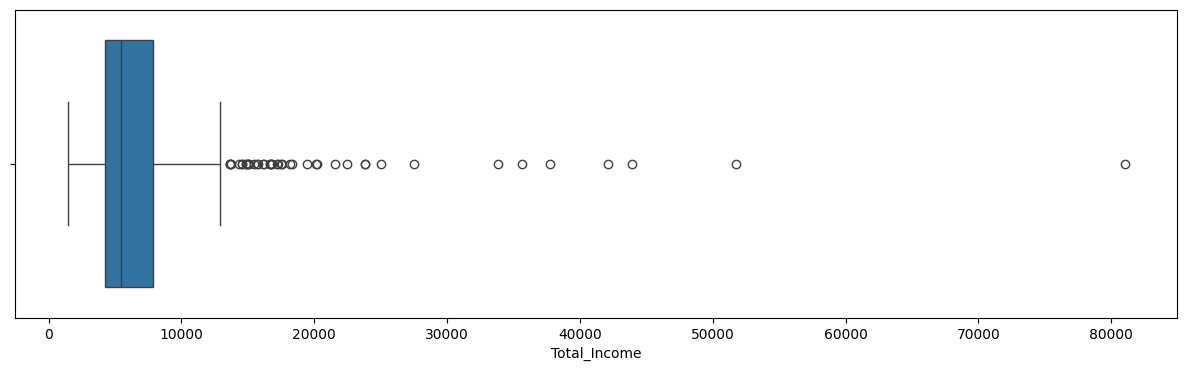

In [27]:
plt.figure(figsize=(15, 4))
sns.boxplot(x = 'Total_Income', data = x_train)

C:\Users\user\AppData\Local\Temp\ipykernel_12648\2049116089.py:15: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train["Total_Income"])
C:\Users\user\AppData\Local\Temp\ipykernel_12648\2049116089.py:19: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_test["Total_Income"])


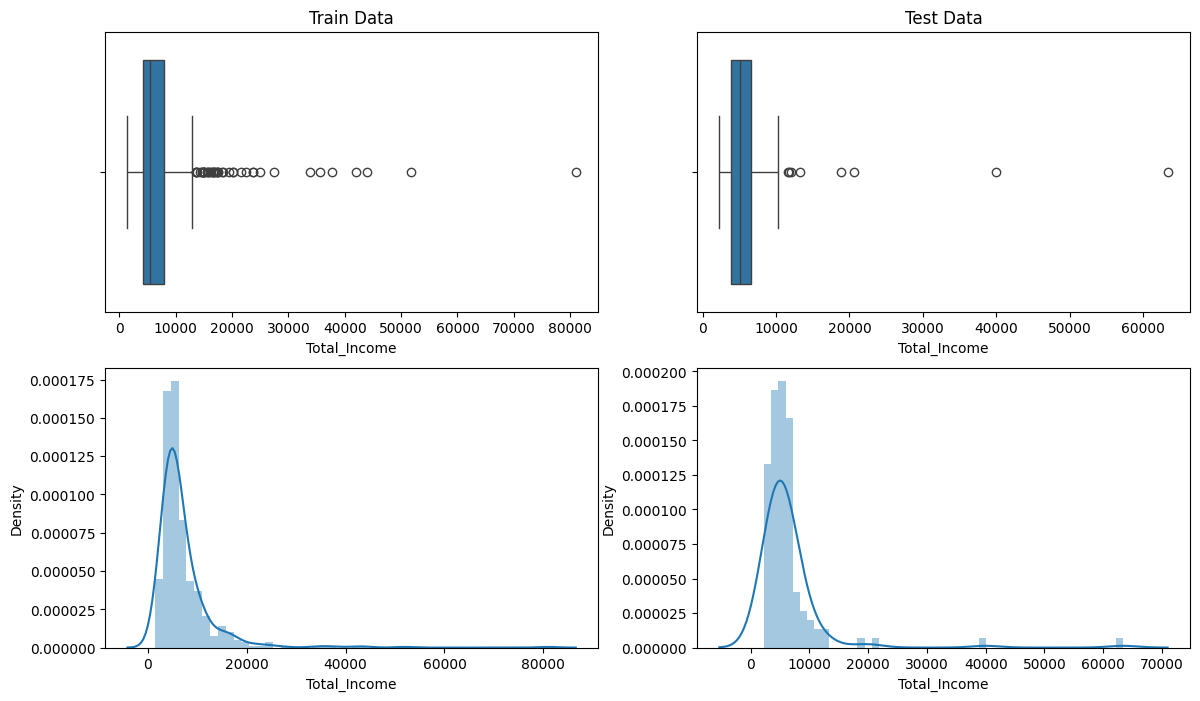

In [28]:
plt.figure(figsize=(14, 8))

# Checking outliers through boxplot
plt.subplot(2,2,1)
plt.title("Train Data")
sns.boxplot(x = 'Total_Income', data = x_train)

# Checking outliers through boxplot
plt.subplot(2,2,2)
plt.title("Test Data")
sns.boxplot(x = 'Total_Income', data = x_test)

# Before Outlier Removal for 'x_train'
plt.subplot(2,2,3) # Means giving the just below plot in the 1st position (i.e. ( , ,1)) with the Single row(i.e. (1, , ), 2 column division(i.e. (,2 ,)) 
sns.distplot(x_train["Total_Income"])

# Before Outlier Removal for 'x_test'
plt.subplot(2,2,4) # Means giving the just below plot in the 1st position (i.e. ( , ,2)) with the Single row(i.e. (1, , ), 2 column division(i.e. (,2 ,)) 
sns.distplot(x_test["Total_Income"])

plt.show()

In [29]:
# We can see that outliers starts approximately from 12500.... something

In [30]:
# We can observe that the tail of the graph goes too long, means there are outliers present!!!

In [31]:
# Outliers can drive to wrong predictions, as they give wrong mean, median, mode, standard deviation O/Ps
# E.g.
l1 = [5, 6, 7, 5, 6, 5, 7.5]
print(f"Mean of l1 = {sum(l1)/len(l1)}")

l2 = [5, 6, 7, 5, 6, 5, 7.5, 100] # Here, 100 is the outlier, which makes mean prediction wrong, i.e., just becoz of a single data row, the prediction will get wrong
print(f"Mean of l2 = {sum(l2)/len(l2)}")

Mean of l1 = 5.928571428571429
Mean of l2 = 17.6875


### i) Outlier removal using IQR (Inter Quantile Range)

In [32]:
x_train.shape # has 491 rows

(491, 10)

In [33]:
q1 = x_train["Total_Income"].quantile(0.25)
q3 = x_train["Total_Income"].quantile(0.75)
IQR = q3 - q1
IQR

np.float64(3614.5)

In [34]:
min_range_iqr = q1 - (1.5*IQR)
max_range_iqr = q3 + (1.5*IQR)
min_range_iqr, max_range_iqr

(np.float64(-1195.25), np.float64(13262.75))

In [35]:
# Here above, 'min_range' comes in -ve, and our dataset 'Total_Income' do not contain anything in -ve, 
# so we can discard 'min_range' value. Also we can see there is no outlier in the left side.

### Removing outliers from original data set

In [36]:
# We will accept those data which have less income than 'max_range' income
df1 = x_train[(x_train["Total_Income"] >= min_range_iqr) & (x_train["Total_Income"] <= max_range_iqr)]
df1.head(2)

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Total_Income
83,Male,Yes,0,Graduate,No,265.0,360.0,1.0,Semiurban,8250.0
90,Male,Yes,0,Graduate,No,131.0,360.0,1.0,Semiurban,5858.0


In [37]:
df1.shape # 448 rows

(448, 10)

In [38]:
# so, after removing outliers, No. of rows removed = 491 - 448 = 43 rows removed

#### After Handling outliers using IQR

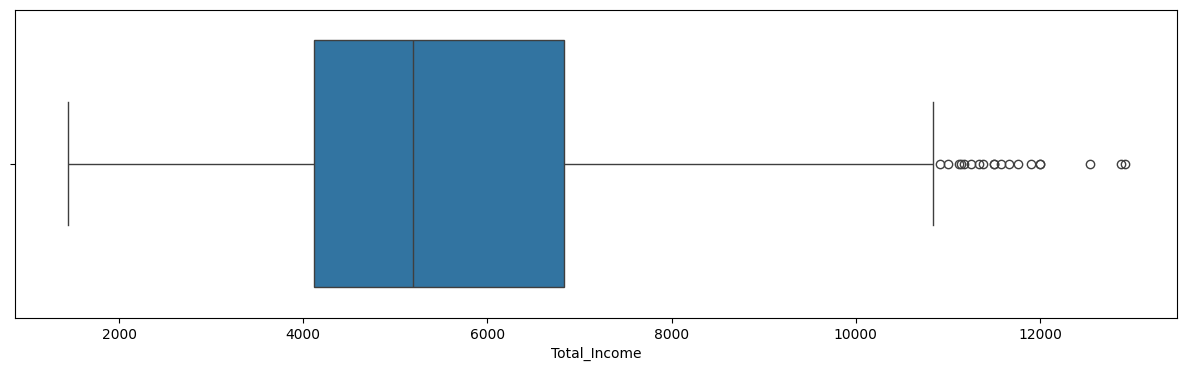

In [39]:
plt.figure(figsize=(15, 4))
sns.boxplot(x = 'Total_Income', data = df1)
plt.show()

In [40]:
# STILL there are many outliers left

##### NOTE: Algos. like DECISION TREE does not depend on the presence of outliers, so, NO need to remove outliers for such algos.
Becoz, removal of Outliers also leads to data loss.
##### But,  Algos. like LINEAR REGRESSION are highly affected by the presence of outliers, so, we NEED to remove outliers for such algos.

### ii) Outlier removal by finding range

In [41]:
# (Mean - 3rd standard deviation) --> min_range
min_range = (x_train["Total_Income"].mean()) - (3 * x_train["Total_Income"].std())

# (Mean + 3rd standard deviation) --> max_range
max_range = (x_train["Total_Income"].mean()) + (3 * x_train["Total_Income"].std())

min_range, max_range

(np.float64(-12042.82780182573), np.float64(26401.096315017745))

In [42]:
df2 = x_train[x_train["Total_Income"] <= max_range]
df2.shape # 446 rows, means 491-446 = 45 rows removed

(483, 10)

<Axes: xlabel='Total_Income'>

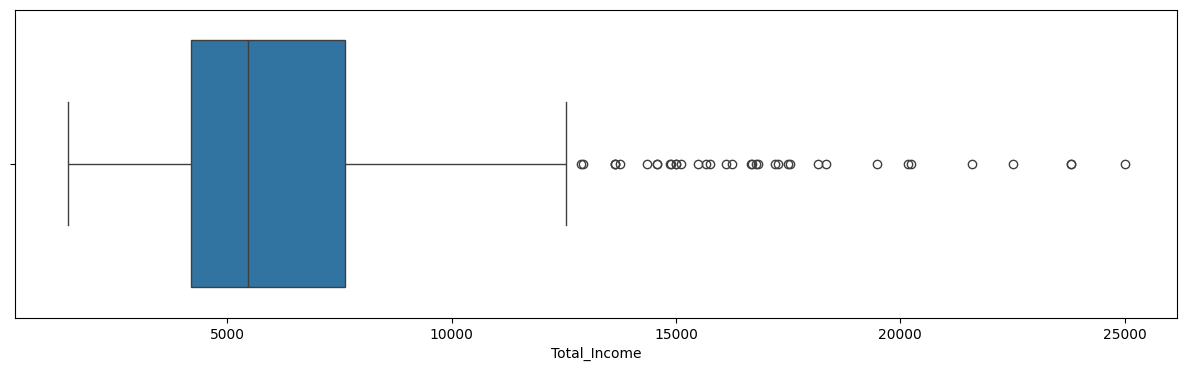

In [43]:
plt.figure(figsize=(15, 4))
sns.boxplot(x="Total_Income", data=df2)

In [44]:
# we can see from above that TOO MANY outliers present. so, it is not a preferred method for this dataset.

### iii) Outlier removal using Z score

In [45]:
# Z = (x - (Mean)) / (standard deviation)
# x --> a data value of a column
# Value of 'Z' decides thee 3rd standard deviation, 
# and data BEFORE (Mean - 3rd standard deviation) and data AFTER (Mean + 3rd standard deviation)
# are considered as outliers

In [46]:
z_score = (x_train["Total_Income"] - x_train["Total_Income"].mean()) / (x_train["Total_Income"].std())

In [47]:
z_score

83     0.167132
90    -0.206191
227    0.119530
482   -0.303736
464   -0.470264
         ...   
71    -0.535190
106    0.837146
270   -0.615255
435    0.447592
102    1.009918
Name: Total_Income, Length: 491, dtype: float64

In [48]:
# z_score > 3 are considered as OUTLIERS, coz 'z_score < 3' contains about 99% of required data, which may not be outliers
z_score > 3

83     False
90     False
227    False
482    False
464    False
       ...  
71     False
106    False
270    False
435    False
102    False
Name: Total_Income, Length: 491, dtype: bool

In [49]:
x_train['z_score'] = z_score

In [50]:
x_train.head(2)

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Total_Income,z_score
83,Male,Yes,0,Graduate,No,265.0,360.0,1.0,Semiurban,8250.0,0.167132
90,Male,Yes,0,Graduate,No,131.0,360.0,1.0,Semiurban,5858.0,-0.206191


In [51]:
df3 = x_train[x_train["z_score"] < 3]
df3.shape

(483, 11)

In [52]:
# We can observe that, the methods ii) and iii) removes same data and same amount of data, so these methods are the same.

#### so, now updating 'x_train' with 'df1'

In [53]:
x_train = df1
x_train.shape

(448, 10)

In [54]:
x_train.head(2)

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Total_Income
83,Male,Yes,0,Graduate,No,265.0,360.0,1.0,Semiurban,8250.0
90,Male,Yes,0,Graduate,No,131.0,360.0,1.0,Semiurban,5858.0


### Applying same boundaries for 'test_dataset'

In [55]:
x_test = x_test[(x_test["Total_Income"] >= min_range_iqr) & (x_test["Total_Income"] <= max_range_iqr)]

In [56]:
x_test.head(2)

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Total_Income
350,Male,Yes,0,Graduate,No,228.0,360.0,1.0,Semiurban,9083.0
377,Male,Yes,0,Graduate,No,130.0,360.0,1.0,Semiurban,4310.0


### After Outlier Removal

C:\Users\user\AppData\Local\Temp\ipykernel_12648\4126424867.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train["Total_Income"])
C:\Users\user\AppData\Local\Temp\ipykernel_12648\4126424867.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_test["Total_Income"])


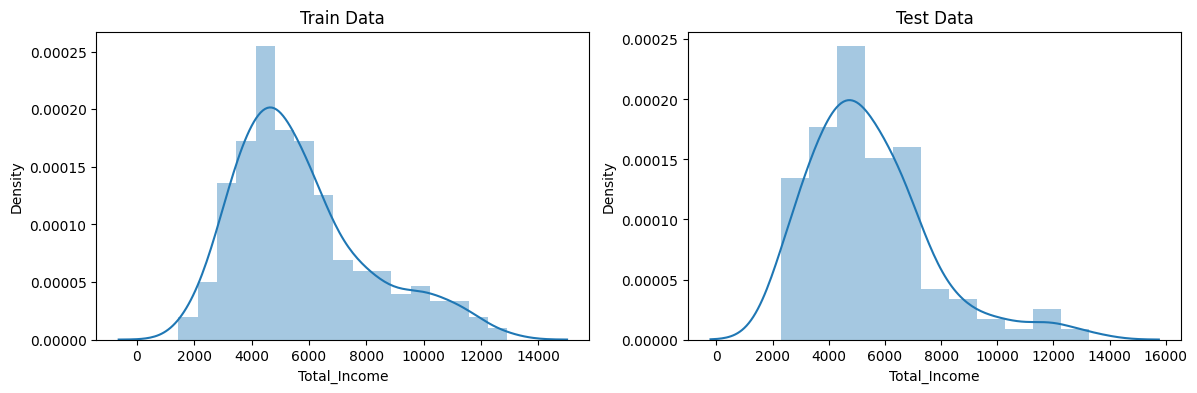

In [64]:
plt.figure(figsize=(14, 4))

# After Outlier Removal in Train Data
plt.subplot(1,2,1) # Means giving the just below plot in the 1st position (i.e. ( , ,1)) with the Single row(i.e. (1, , ), 2 column division(i.e. (,2 ,)) 
plt.title("Train Data")
sns.distplot(x_train["Total_Income"])

# After Outlier Removal Test Data
plt.subplot(1,2,2) # Means giving the just below plot in the 1st position (i.e. ( , ,2)) with the Single row(i.e. (1, , ), 2 column division(i.e. (,2 ,)) 
plt.title("Test Data")
sns.distplot(x_test["Total_Income"])

plt.show()

In [58]:
print(type(x_test))
print(x_test.shape)
print(x_test.columns)

<class 'pandas.DataFrame'>
(119, 10)
Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area',
       'Total_Income'],
      dtype='str')


#

### Checking for Outliers in 'LoanAmount'

### Before Handling outliers

<Axes: xlabel='LoanAmount'>

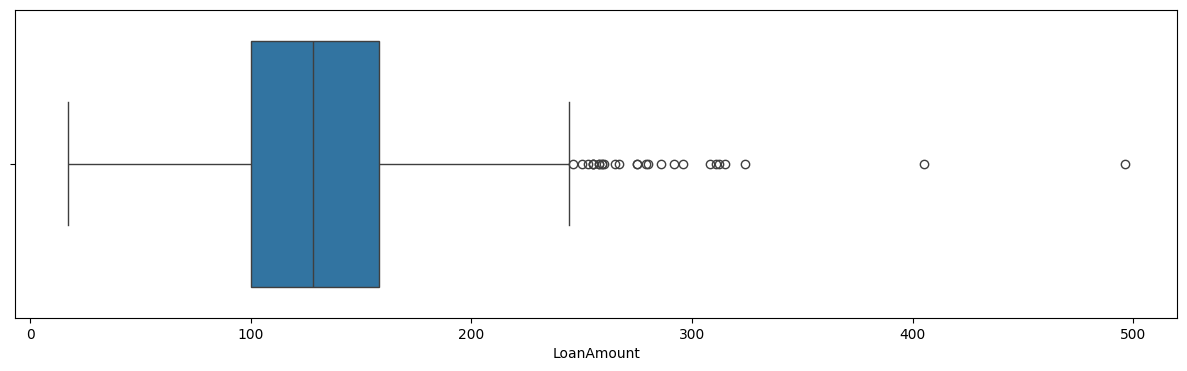

In [59]:
plt.figure(figsize=(15, 4))
sns.boxplot(x = 'LoanAmount', data = x_train)

In [60]:
print(x_train.columns) # If no error, means, x_train is still a DataFrame
print(x_test.columns) # If no error, means, x_tesgt is still a DataFrame

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area',
       'Total_Income'],
      dtype='str')
Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area',
       'Total_Income'],
      dtype='str')


#

### Checking for Outliers in 'Loan_Amount_Term'

### Before Handling outliers

<Axes: xlabel='Loan_Amount_Term'>

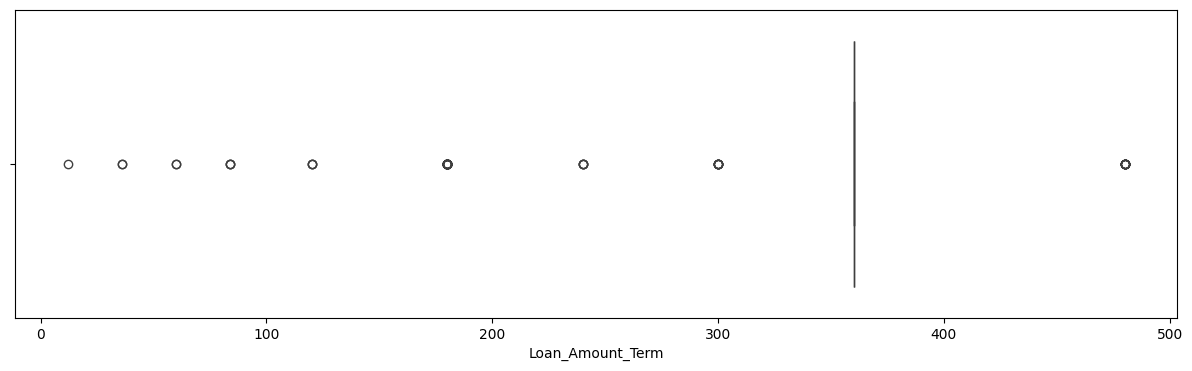

In [61]:
plt.figure(figsize=(15, 4))
sns.boxplot(x = 'Loan_Amount_Term', data = x_train)

#

#### ALREADY MUCH DATA REMOVED THROUGH OUTLIER REMOVAL DUE TO 'Total_Income', NOW NOT MUCH OUTLIERS LEFT FOR REMAINING, 
#### SO NO NEED TO REMOVE ANYB MORE ROWS